# NNMF analysis

Run the setup cell first. It opens one window to choose the working folder, input file format (`.txt` or `.csv`), reference workbook, data subfolders, and analysis parameters. The window previews ten raw spectra; drag to select the baseline band or the shared fit/output range. Then run the remaining cells from top to bottom to inspect preprocessing, fit all original spectra , export results, and create plots. Rerun the setup cell to configure a new analysis.

Each original spectrum has its baseline removed, is scaled at NV0, cropped, and normalized by its own trapezoidal area. Folder averages are arithmetic means for inspection/export only.

NNMF learns shared shapes from all selected original spectra together. When reference initialization is enabled, one replicate starts from workbook references and the remaining replicates start randomly. If `INIT_COMP` is `0`, the setup checkbox can instead fit one Gaussian reference curve per component, save the curves to `export/ref.xlsx`, and use them for NNMF initialization. 

`MAX_ITERATIONS` is the maximum number of coordinate-descent updates allowed per replicate 

`NNMF_REPLICATES` is how many times it tries the whole fit from different starting guesses

`RANDOM_SEED` controls the random initialization sequence

In the default settings, the script uses `NNMF_REPLICATES = 20`, `MAX_ITERATIONS = 100`, and `RANDOM_SEED = 21`.

Results are saved under `export/`, with figures in `export/figures/` and folder averages in `export/folder_averages/`.

In [2]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nnmf_full_fixed_jh_V3 as nnmf
nnmf = importlib.reload(nnmf)

COMPONENT_NAMES = ["C1", "C2", "C3", "C4"]
DEFAULT_ANALYSIS_PARAMETERS = {
    "COMPONENTS": 2,
    "INIT_COMP": 2,
    "BASEMEAN_LOWER": 377,
    "BASEMEAN_UPPER": 480,
    "THRESHOLD_LOWER": 540,
    "THRESHOLD_UPPER": 900,
    "NNMF_REPLICATES": 20,
    "MAX_ITERATIONS": 100,
    "RANDOM_SEED": 21,
    "NNMF_NEGATIVE_TOLERANCE": 5e-4,
    "NV0": 575,
    "NVN": 640,
    "USE_GAUSSIAN_REFERENCE": False,
    "SHOW_COMPARED": True,
}

nnmf.configure_analysis({
    "DATA_FOLDER": Path.cwd(),
    "INPUT_FORMAT": "txt",
    "REFERENCE_FILE": None,
    "COMPONENT_NAMES": COMPONENT_NAMES,
    "EXPORT_FOLDER": "export",
    "FIGURE_FOLDER": "figures",
    "TRAPZ_DATA_FOLDERS": [],
    "ARIT_DATA_FOLDERS": [],
    "COLOURS": nnmf.prism_colours(4),
    "CHANGE_NAME": True,
    "OWN_AXIS": False,
    "X_AXIS_FILE": "X.txt",
    "UPDATE_FILES": True,
    **DEFAULT_ANALYSIS_PARAMETERS,
})

SETUP = nnmf.select_analysis_setup(
    Path.cwd(), None, COMPONENT_NAMES, DEFAULT_ANALYSIS_PARAMETERS
)
DATA_FOLDER = SETUP["DATA_FOLDER"]
INPUT_FORMAT = SETUP["INPUT_FORMAT"]
REFERENCE_FILE = SETUP["REFERENCE_FILE"]
LIST_OF_DATA_FOLDERS = SETUP["LIST_OF_DATA_FOLDERS"]
ANALYSIS_PARAMETERS = SETUP["parameters"]
globals().update(ANALYSIS_PARAMETERS)
TRAPZ_DATA_FOLDERS = []
ARIT_DATA_FOLDERS = LIST_OF_DATA_FOLDERS.copy()

nnmf.configure_analysis({
    "DATA_FOLDER": DATA_FOLDER,
    "INPUT_FORMAT": INPUT_FORMAT,
    "REFERENCE_FILE": REFERENCE_FILE,
    "EXPORT_FOLDER": "export",
    "FIGURE_FOLDER": "figures",
    "LIST_OF_DATA_FOLDERS": LIST_OF_DATA_FOLDERS,
    "TRAPZ_DATA_FOLDERS": TRAPZ_DATA_FOLDERS,
    "ARIT_DATA_FOLDERS": ARIT_DATA_FOLDERS,
    "COMPONENT_NAMES": COMPONENT_NAMES,
    **ANALYSIS_PARAMETERS,
    "COLOURS": nnmf.prism_colours(4),
    "CHANGE_NAME": True,
    "OWN_AXIS": False,
    "X_AXIS_FILE": "X.txt",
    "UPDATE_FILES": True,
})
EXPORT_DIR = DATA_FOLDER / "export"
FIGURE_DIR = EXPORT_DIR / "figures"
print(f"Working folder: {DATA_FOLDER}")
print(f"Reference workbook: {REFERENCE_FILE}")
print(f"Selected data folders: {LIST_OF_DATA_FOLDERS}")
print(f"Fit components: {COMPONENTS}")
print(f"Reference-initialized components: {INIT_COMP}")


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
print(f"Data folder: {DATA_FOLDER}")
print(f"Reference workbook: {REFERENCE_FILE}")
print(f"Data folders: {', '.join(LIST_OF_DATA_FOLDERS)}")
print(f"Baseline band: {BASEMEAN_LOWER}-{BASEMEAN_UPPER} nm")
print(f"Fit range: >{THRESHOLD_LOWER} to {THRESHOLD_UPPER} nm")


Data folder: C:\Users\nejde\OneDrive - VŠCHT\Plocha\Cigler\nnmf\DATA\2026-05-05 PTQ Diamond Nanoparticles
Reference workbook: None
Data folders: PTQ 32 1500C, PTQ 33 1550C, PTQ 34 1600C, PTQ 43 1700C, PTQ 44 1750C, PTQ 45 1675C, PTQ 62 1850C, PTQ 63 1900C, PTQ 64 1800C
Baseline band: 1291.89-1337.38 nm
Fit range: >848.819 to 1337.15 nm


#### 1. Prepare corrected originals and arithmetic folder averages

Each original spectrum is baseline-corrected using its own local baseline band (`BASEMEAN_LOWER` to `BASEMEAN_UPPER`). Spectra recorded on different wavelength grids are interpolated onto a common grid before folder averaging (`X.txt`). The folder averages are kept for inspection/export; the individual spectra are the actual inputs to NNMF.

The relevant preprocessing logic is in `prepare_analysis_spectra()` and `subtract_spectrum_baseline()` in `nnmf_full_fixed_jh_V3.py`.

##### `TRAPZ_DATA_FOLDERS` and `ARIT_DATA_FOLDERS`

Use `TRAPZ_DATA_FOLDERS` when you want a folder-average shape that is insensitive to total intensity differences between spectra; use `ARIT_DATA_FOLDERS` when you want the average to retain the absolute signal level. In this notebook workflow, these lists are mainly for comparison/inspection and are not the matrix used for the final NNMF fit; the NNMF fit uses the individual normalized spectra, not the averaged folder curves.

- `TRAPZ_DATA_FOLDERS`: for folders in this list, each corrected spectrum is normalized by its trapezoidal area before averaging:
  - `y_corr = spectrum[:, 1] - min(spectrum[:, 1])`
  - `area = trapezoid(y_corr)`
  - `y_norm = y_corr / area`
  - average over the normalized spectra
- `ARIT_DATA_FOLDERS`: for folders in this list, the folder average is the simple arithmetic mean over the aligned spectra:
  - `mean_y = mean(spectrum_y_values, axis=0)`



In [ ]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
average_files, individual_files, sample_folders, filenames = nnmf.prepare_analysis_spectra(EXPORT_DIR)
average_wavelength, average_spectra, average_names = nnmf.assemble_tables(
    average_files, EXPORT_DIR / "folder_averages"
)
individual_wavelength, spectra, _ = nnmf.assemble_tables(individual_files, EXPORT_DIR)
print(f"Prepared {len(average_names)} folder averages and {len(filenames)} original spectra.")


Prepared 9 folder averages and 101 original spectra.


#### 2. Normalize and crop for NNMF

For each original spectrum separately:

1. subtract the spectrum-specific baseline,
2. divide by the corrected intensity at the wavelength nearest `NV0`,
3. keep only the selected fit range `THRESHOLD_LOWER < wavelength <= THRESHOLD_UPPER`,
4. divide by the spectrum's own trapezoidal area.

The actual transformation is:

`scaled = spectrum / spectrum[nearest(NV0)]`

`selected = wavelength > THRESHOLD_LOWER and wavelength <= THRESHOLD_UPPER`

`area = trapezoid(scaled[selected], axis=0)`

`normalized = scaled[selected] / area`

This makes each spectrum comparable in shape while preserving relative peak positions. After preprocessing, the data matrix has shape `(wavelengths, spectra)`, so each column is one normalized spectrum and the whole matrix is the NNMF input.


In [ ]:
average_fit_wavelength, average_normalized = nnmf.normalize_spectra(
    average_wavelength, average_spectra, average_names
)
fit_wavelength, normalized = nnmf.normalize_spectra(
    individual_wavelength, spectra, filenames
)
print(f"NNMF input matrix: {normalized.shape} (wavelengths, original spectra)")


NNMF input matrix: (1003, 101) (wavelengths, original spectra)


#### 3. Reference spectra vs. fitted Gaussian reference

The setup window selects the data folder, included subfolders, fit settings, and optional reference workbook. `INIT_COMP` is the number of workbook spectra used to seed the initial matrix; set it to `0` to skip workbook loading.

When `INIT_COMP = 0` and `USE_GAUSSIAN_REFERENCE` is enabled, the code calls `fit_gaussian_reference_curves()` in `nnmf_full_fixed_jh_V3.py`. It builds a shared Gaussian basis

`g(x; mu, sigma) = exp(-0.5 * ((x - mu) / sigma)^2)`

and fits one Gaussian per component to the mean spectrum across all selected spectra. `scipy.signal.find_peaks` is applied to the mean curve to find possible peak centers, the strongest peaks are ranked, and several combinations of possible centers are used as starting values for a bounded `scipy.optimize.least_squares` optimization. The optimization adjusts the centers `mu_k` and widths `sigma_k`, while each spectrum gets its own nonnegative amplitudes through `scipy.optimize.nnls` on the Gaussian basis. The fitted curves are saved to `export/ref.xlsx` and then used as NNMF initialization. When `INIT_COMP > 0`, the workbook itself seeds the first replicate; the remaining replicates start randomly.

The Gaussian option is only a better starting guess, not a final answer: NNMF is then allowed to refine the shared shapes freely.

Values in the interval `[-NNMF_NEGATIVE_TOLERANCE, 0)` are forced to zero before NNMF. This is done because the code expects a nonnegative matrix for NMF. If negative values are more negative than this tolerance, the code raises an error and stops.


PTQ 32 1500C/PTQ 32 785nm_1000uW p 01.csv negative points: 50 minimum: -4.45918e-05 at 1311.02 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 02.csv negative points: 47 minimum: -2.01381e-05 at 1334.83 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 03.csv negative points: 61 minimum: -8.21136e-05 at 1286.68 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 04.csv negative points: 49 minimum: -3.72259e-05 at 1327.22 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 05.csv negative points: 63 minimum: -9.4572e-05 at 1326.27 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 06.csv negative points: 62 minimum: -8.9395e-05 at 1290.50 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 07.csv negative points: 45 minimum: -2.04679e-05 at 1332.93 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 08.csv negative points: 57 minimum: -8.04083e-05 at 1323.89 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 09.csv negative points: 46 minimum: -3.03817e-05 at 1334.83 nm
PTQ 32 1500C/PTQ 32 785nm_1000uW p 10.csv negative points: 45 minimum: -2.6395e-05 at 1336.26 nm
PTQ 32 1500C/PTQ 32 785

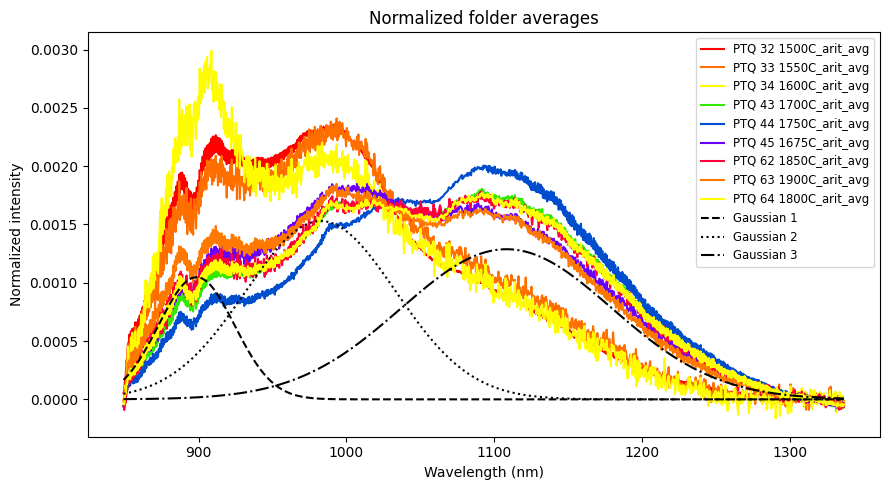

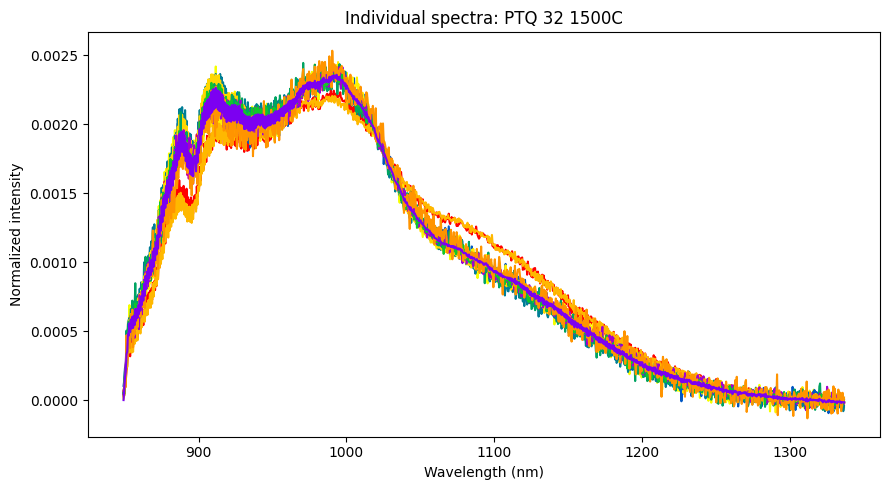

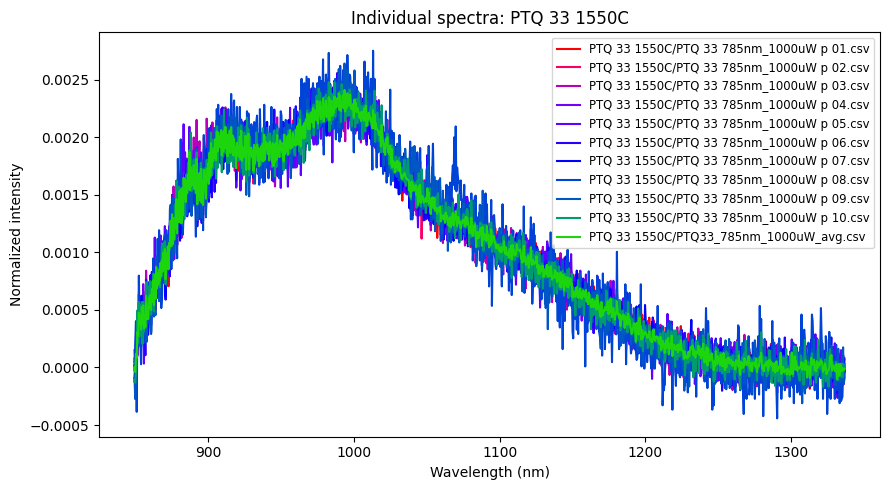

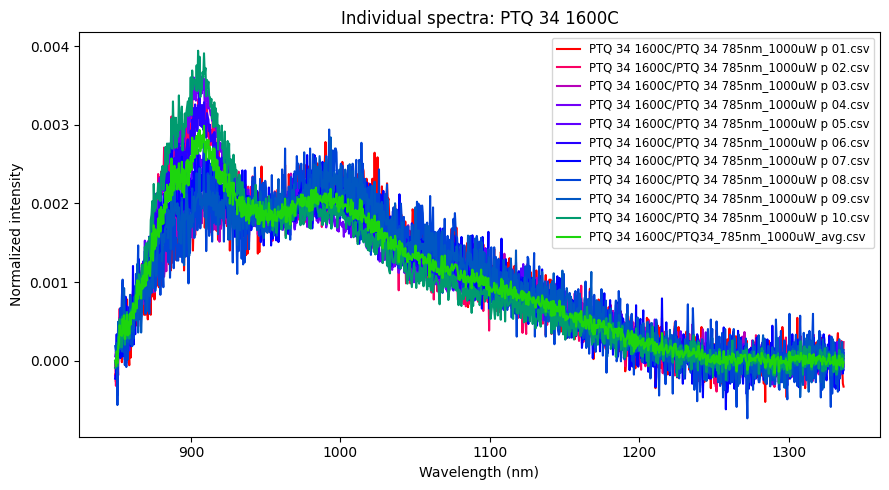

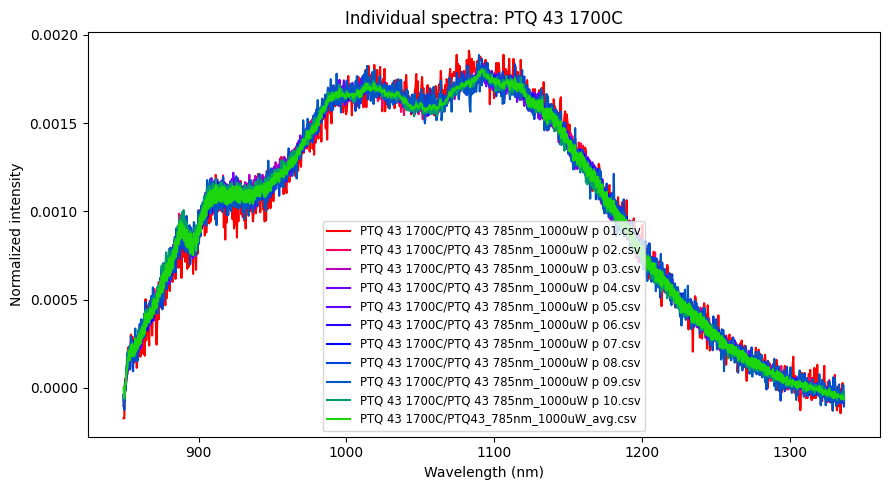

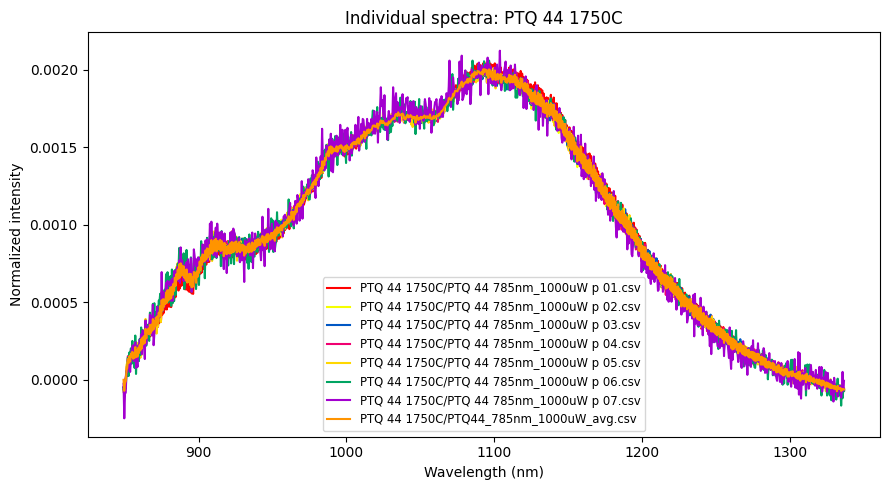

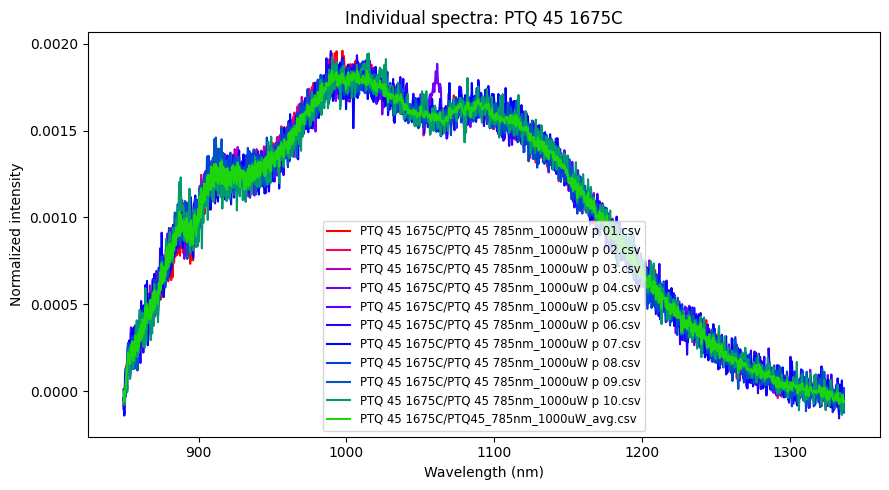

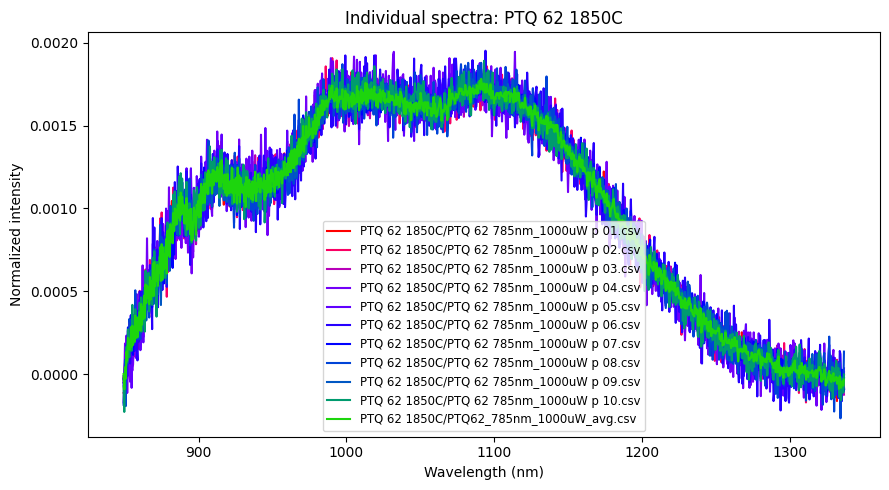

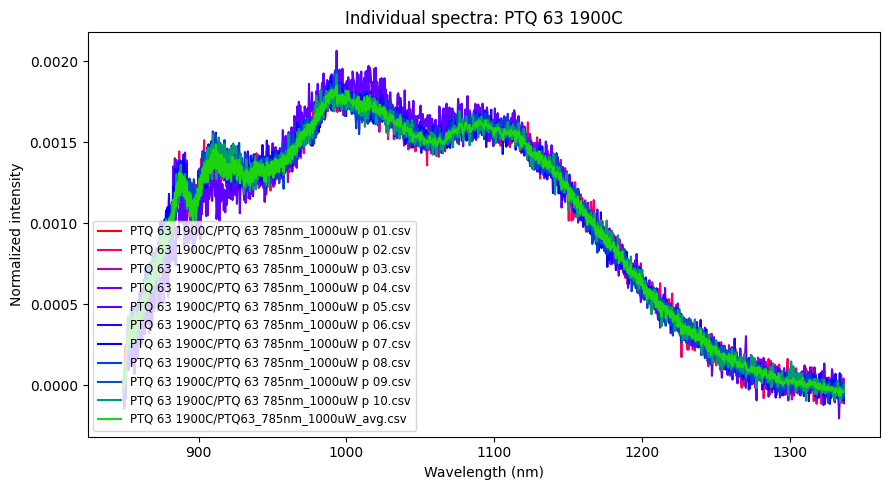

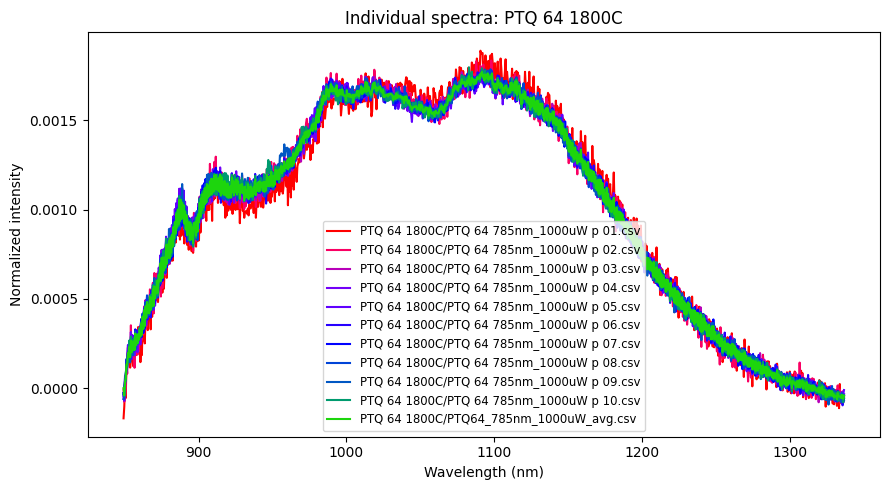

In [ ]:
reference_spectra_for_plot = None
reference_names_for_plot = None
reference_area_fractions = None
if INIT_COMP > 0:
    reference_names_for_plot = [f"Reference {index + 1}" for index in range(INIT_COMP)]
    reference_values = nnmf.load_reference_spectra(average_wavelength, INIT_COMP)
    reference_wavelength, reference_spectra_for_plot = nnmf.normalize_spectra(
        average_wavelength, reference_values, reference_names_for_plot
    )
    if not np.array_equal(reference_wavelength, average_fit_wavelength):
        reference_spectra_for_plot = np.column_stack([
            np.interp(average_fit_wavelength, reference_wavelength, reference_spectra_for_plot[:, index], left=0.0, right=0.0)
            for index in range(reference_spectra_for_plot.shape[1])
        ])
    initial_w = nnmf.load_reference_initialization(fit_wavelength)
elif USE_GAUSSIAN_REFERENCE:
    initial_w, reference_area_fractions = nnmf.fit_gaussian_reference_curves(
        fit_wavelength, normalized, COMPONENTS,
        reference_path=EXPORT_DIR / "ref.xlsx",
    )
    reference_names_for_plot = [f"Gaussian {index + 1}" for index in range(COMPONENTS)]
    reference_spectra_for_plot = np.column_stack([
        np.interp(average_fit_wavelength, fit_wavelength, initial_w[:, index], left=0.0, right=0.0)
        for index in range(COMPONENTS)
    ])
    REFERENCE_FILE = EXPORT_DIR / "ref.xlsx"
    nnmf.REFERENCE_FILE = REFERENCE_FILE
else:
    initial_w = None

nnmf.plot_processed_spectra(
    average_fit_wavelength, average_normalized, average_names,
    fit_wavelength, normalized, filenames, sample_folders, FIGURE_DIR,
    reference_spectra=reference_spectra_for_plot,
    reference_names=reference_names_for_plot,
    reference_area_fractions=reference_area_fractions,
)
negative_counts = np.sum(normalized < 0, axis=0)
for sample_index in np.flatnonzero(negative_counts):
    wavelength_index = np.argmin(normalized[:, sample_index])
    print(filenames[sample_index],
          f"negative points: {negative_counts[sample_index]}",
          f"minimum: {normalized[wavelength_index, sample_index]:.6g}",
          f"at {fit_wavelength[wavelength_index]:.2f} nm")
if SHOW_COMPARED:
    plt.show()


#### 4. NNMF fit

The NNMF step fits a single matrix factorization for all selected spectra at once:

`V ≈ W * H`

where `V` is the `(wavelengths x spectra)` matrix, `W` is the `(wavelengths x components)` matrix, and `H` is the `(components x spectra)` coefficient matrix. Each column of `W` is a common spectral component; each column of `H` contains the weights for one sample.

The work is done in `fit_nmf()` and `fit_joint_spectra()` in `nnmf_full_fixed_jh_V3.py` using `sklearn.decomposition.NMF` with `n_components = COMPONENTS`, `solver = "cd"`, and `max_iter = MAX_ITERATIONS`.

The code runs `NNMF_REPLICATES` independent fits and keeps the one with the lowest reconstruction error `||V - W H||_F`. The first replicate can start from a workbook or Gaussian initialization; the remaining replicates start with random initial values. This is a standard way to reduce the risk of convergence to a poor local minimum. `RANDOM_SEED` is the base seed for reproducibility; the actual random state is `RANDOM_SEED + replicate`, so every replicate is deterministic but different.


In [ ]:
approximations, weighting = nnmf.fit_joint_spectra(normalized, initial_w, filenames)

wavelength = fit_wavelength
measured = normalized
shared_shapes = approximations
components = shared_shapes[:, None, :] * weighting.T[None, :, :]
fitted = np.sum(components, axis=2)
print(f"Joint fit completed: {len(filenames)} spectra")
print(f"Shared shapes: {approximations.shape}; per-spectrum weights: {weighting.shape}")


Joint fit completed: 101 spectra
Shared shapes: (1003, 3); per-spectrum weights: (3, 101)


### 5. Export fitted results and fit quality

The fit results are exported as `spect.xlsx` and `ratios.xlsx` in the analysis `export/` folder. `spect.xlsx` contains the measured spectra, the weighted component curves, and the reconstructed fit for each original. `ratios.xlsx` stores relative component area fractions and fit-quality metrics for each original spectrum, plus a summary row across all spectra.

The relevant calculations are based on the trapezoidal area of each component over the fit range, so the component contributions are area-normalized percentages.


In [ ]:
ratios_df = nnmf.export_fit_results(
    EXPORT_DIR, wavelength, measured, components, fitted, filenames, sample_folders
)
display(ratios_df.round(4))
print(f"Saved results to {EXPORT_DIR}")


,#,Filename,Folder,C1 [%],C2 [%],C3 [%],check_sum,CORR,DEV
0,-1,All,All,38.0399,21.3839,40.5763,100.0,0.9999,0.0000
1,1,PTQ 32 1500C/PTQ 32 785nm_1000uW p 01.csv,PTQ 32 1500C,71.2228,12.3509,16.4263,100.0,0.9981,0.0000
2,2,PTQ 32 1500C/PTQ 32 785nm_1000uW p 02.csv,PTQ 32 1500C,74.4792,21.3043,4.2164,100.0,0.9982,0.0001
3,3,PTQ 32 1500C/PTQ 32 785nm_1000uW p 03.csv,PTQ 32 1500C,72.5135,24.1620,3.3245,100.0,0.9982,0.0001
4,4,PTQ 32 1500C/PTQ 32 785nm_1000uW p 04.csv,PTQ 32 1500C,73.7040,22.5250,3.7710,100.0,0.9984,0.0000
...,...,...,...,...,...,...,...,...,...
97,97,PTQ 64 1800C/PTQ 64 785nm_1000uW p 07.csv,PTQ 64 1800C,18.7834,20.3449,60.8717,100.0,0.9988,0.0000
98,98,PTQ 64 1800C/PTQ 64 785nm_1000uW p 08.csv,PTQ 64 1800C,19.7518,19.0334,61.2148,100.0,0.9989,0.0000
99,99,PTQ 64 1800C/PTQ 64 785nm_1000uW p 09.csv,PTQ 64 1800C,20.0289,19.6280,60.3432,100.0,0.9987,0.0000
100,100,PTQ 64 1800C/PTQ 64 785nm_1000uW p 10.csv,PTQ 64 1800C,19.5093,19.7802,60.7105,100.0,0.9988,0.0000


Saved results to C:\Users\nejde\OneDrive - VŠCHT\Plocha\Cigler\nnmf\DATA\2026-05-05 PTQ Diamond Nanoparticles\export


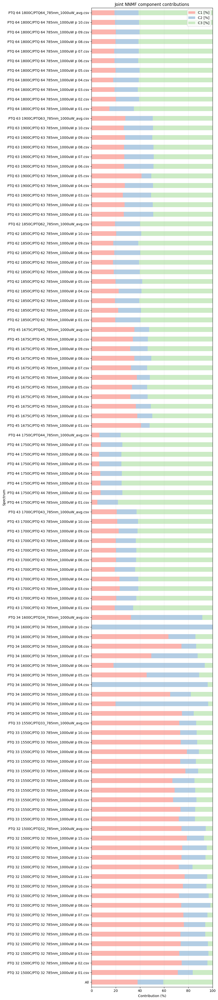

In [ ]:
component_columns = [
    f"{name} [%]" for name in nnmf.display_component_names()[:COMPONENTS]
]
plot_ratios = ratios_df.set_index("Filename")[component_columns]
axis = plot_ratios.plot(
    kind="barh", stacked=True,
    figsize=(9, max(3, 0.4 * len(plot_ratios))),
    color=nnmf.pastel_colours(COMPONENTS),
)
axis.set_xlabel("Contribution (%)")
axis.set_ylabel("Spectrum")
axis.set_title("Joint NNMF component contributions")
axis.set_xlim(0, 100)
axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
if SHOW_COMPARED:
    plt.show()
else:
    plt.close(axis.figure)


### 6. Plot component shapes and fits


c:\Users\nejde\OneDrive - VŠCHT\Plocha\Cigler\nnmf\Scripts\nnmf_full_fixed_jh_V3.py:1421: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure, axis = plt.subplots(figsize=(9, 5))


Plots saved to C:\Users\nejde\OneDrive - VŠCHT\Plocha\Cigler\nnmf\DATA\2026-05-05 PTQ Diamond Nanoparticles\export\figures


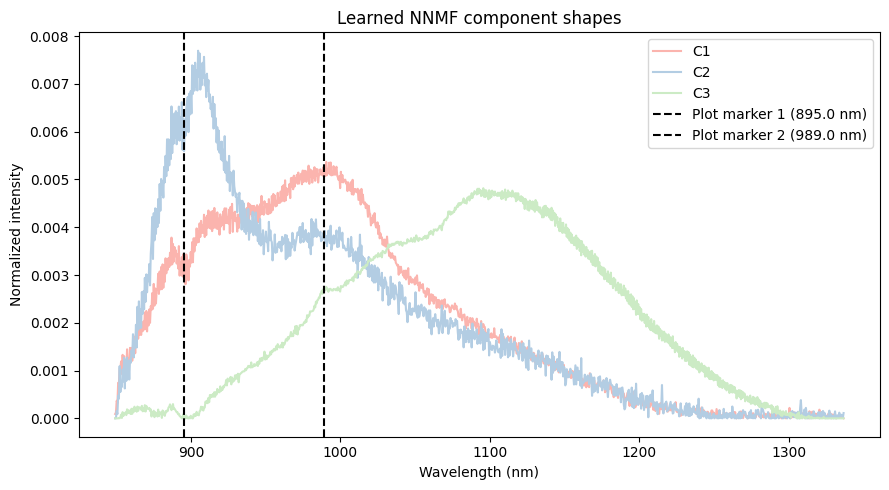

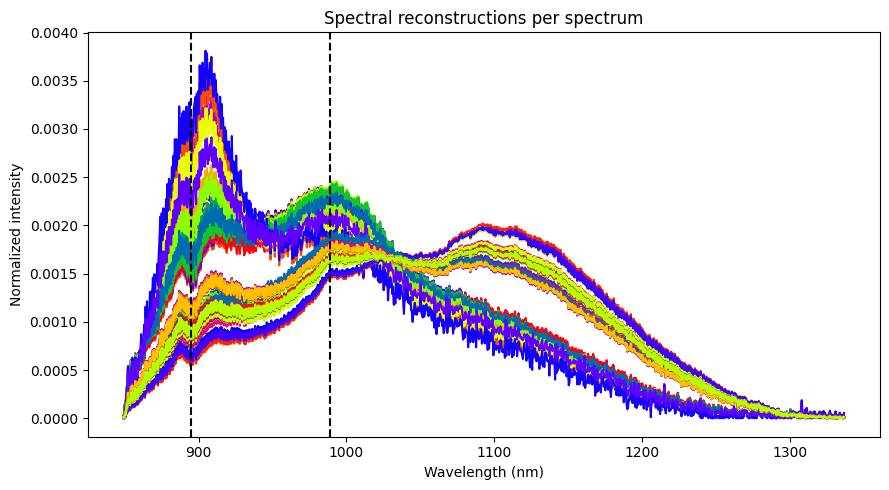

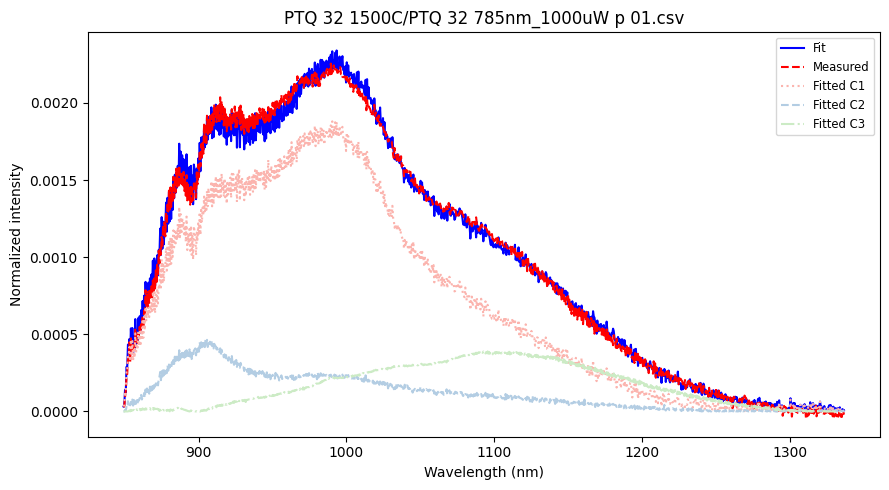

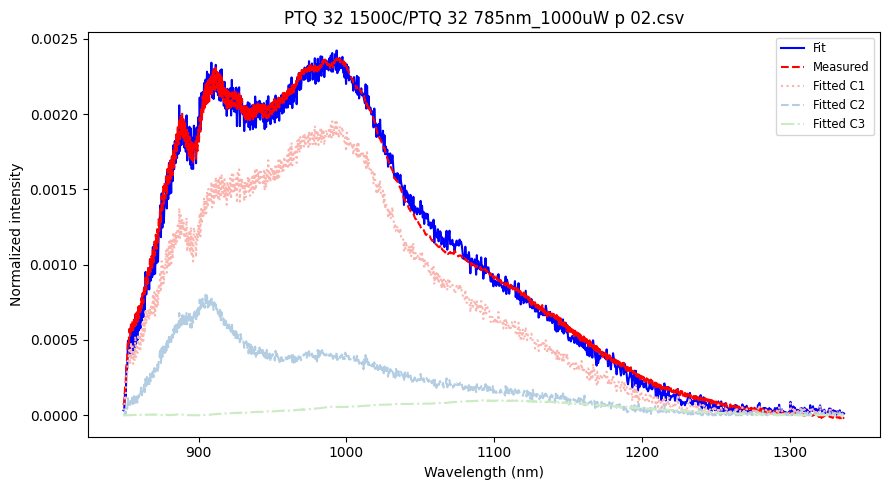

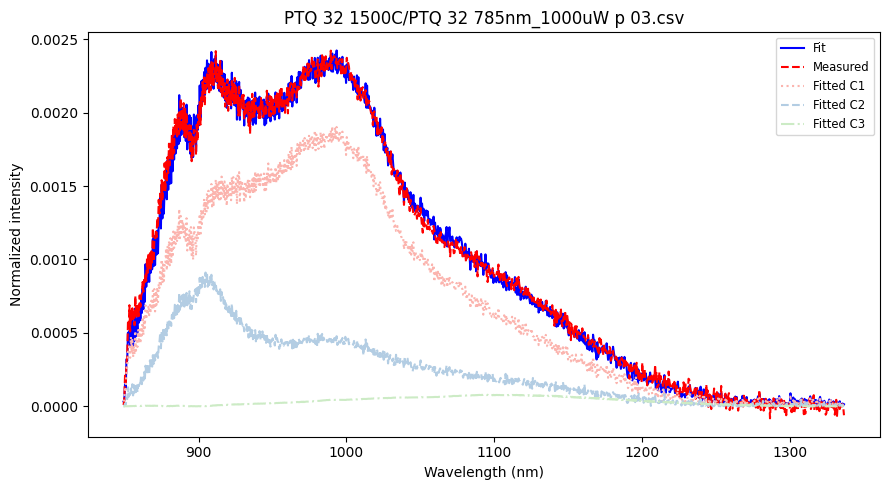

...

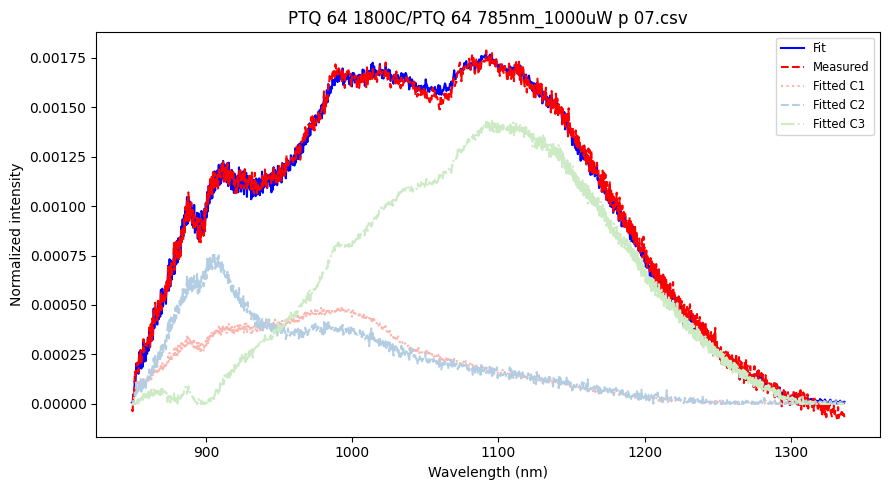

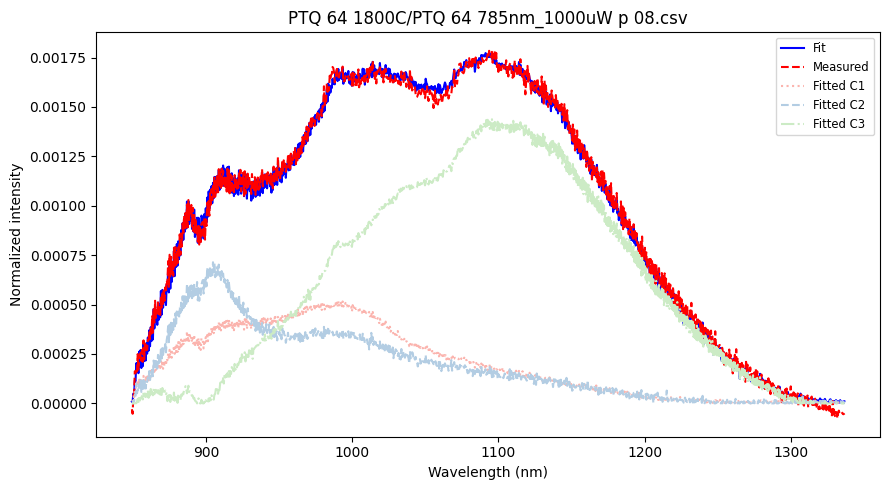

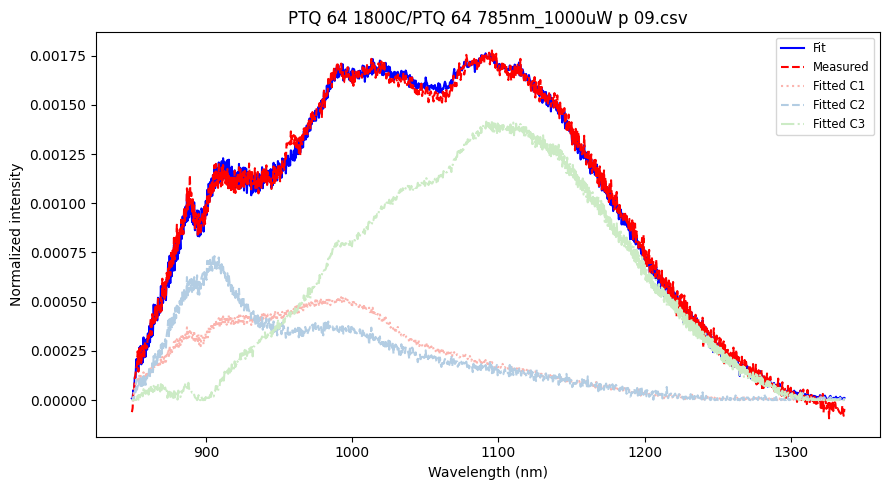

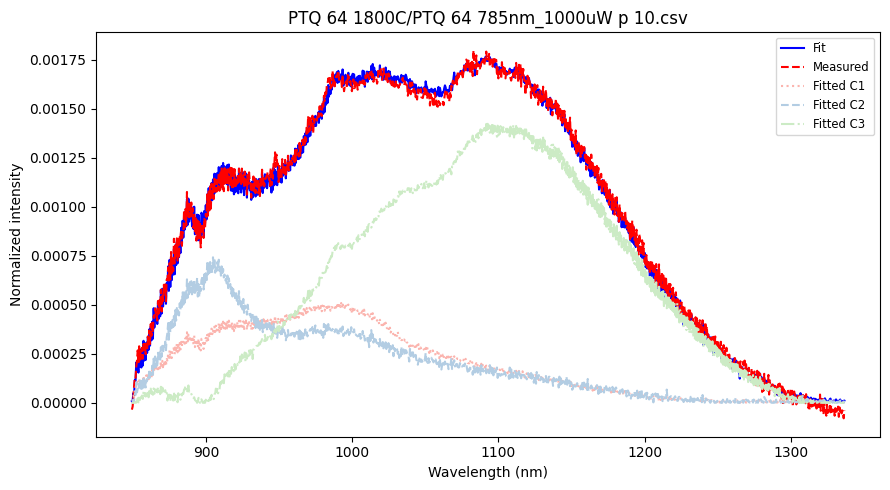

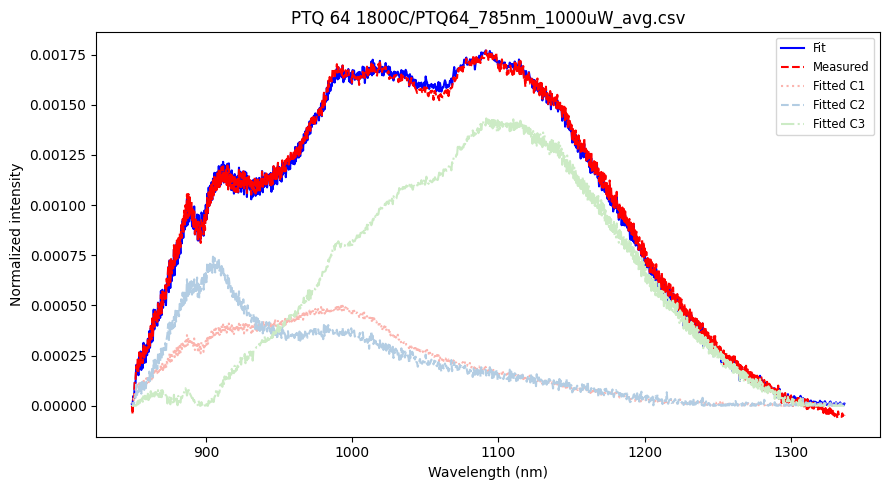

In [ ]:
nnmf.plot_shared_component_shapes(wavelength, shared_shapes, FIGURE_DIR)
nnmf.plot_fit_overviews(wavelength, fitted, filenames, FIGURE_DIR)
nnmf.plot_individual_fits(
    wavelength=wavelength,
    measured=measured,
    fitted=fitted,
    components=components,
    filenames=filenames,
    figure_dir=FIGURE_DIR,
)
print(f"Plots saved to {FIGURE_DIR}")
if SHOW_COMPARED:
    plt.show()
